# Spring 26 LLMs Workshop

March 2, 2026  
Part 2, Phase 1

We fine tune a model on company policy Q and A.

## Check runtime and GPU

In [6]:
import sys, platform
import torch

print("Python:", sys.version)
print("Platform:", platform.platform())
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Capability:", torch.cuda.get_device_capability(0))


Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Platform: Linux-6.6.113+-x86_64-with-glibc2.35
Torch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB
Capability: (8, 0)


## Install required libraries

In [7]:
%pip -q install -U pip setuptools wheel

%pip -q install -U   "transformers==5.0.0"   "trl==0.27.1"   "peft==0.18.1"   "accelerate==1.12.0"   "bitsandbytes==0.49.1"   "datasets>=2.18.0"   "huggingface_hub>=0.23.0"   "sentencepiece"   "safetensors"   "tensorboard"


## Import packages

In [8]:
import os
import gc
import re
import string
import random
import numpy as np
import torch

from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from transformers import logging as hf_logging

from peft import LoraConfig, PeftModel, prepare_model_for_kbit_training
from trl import SFTTrainer, SFTConfig

hf_logging.set_verbosity_error()

def cuda_cleanup():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

def print_trainable_params(model):
    trainable = 0
    total = 0
    for _, p in model.named_parameters():
        n = p.numel()
        total += n
        if p.requires_grad:
            trainable += n
    pct = 100 * trainable / max(total, 1)
    print(f"Trainable params: {trainable:,}")
    print(f"Total params:     {total:,}")
    print(f"Trainable %:      {pct:.4f}%")

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


## Set config

In [9]:
# Base model (same style as the sample notebook)
model_name = "NousResearch/Llama-2-7b-chat-hf"

# Dataset: company privacy policies Q/A
dataset_name = "alzoubi36/privacy_qa"
DATASET_URL = "https://huggingface.co/datasets/alzoubi36/privacy_qa"

# Keep exactly 5000 for train, up to 100 for eval
TRAIN_N = 5000

# Output names
adapter_dir = "Spring26_privacy_qa_lora_adapter"
output_dir = "./results"

seed = 42
set_seed(seed)

# QLoRA (4-bit)
use_4bit = True
bnb_4bit_quant_type = "nf4"
use_nested_quant = False
compute_dtype = torch.bfloat16 if (torch.cuda.is_available() and torch.cuda.get_device_capability(0)[0] >= 8) else torch.float16
device_map = "auto"

# LoRA config
lora_r = 16
lora_alpha = 32
lora_dropout = 0.05
lora_target_modules = ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]

# Training
num_train_epochs = 1
per_device_train_batch_size = 1
gradient_accumulation_steps = 4
gradient_checkpointing = True

learning_rate = 1e-4
weight_decay = 0.0
max_grad_norm = 0.3
warmup_ratio = 0.03
lr_scheduler_type = "cosine"

logging_steps = 10
save_strategy = "no"

max_seq_length = 768
packing = False

print("Dataset:", dataset_name)
print("Dataset URL:", DATASET_URL)
print("compute_dtype:", compute_dtype)


Dataset: alzoubi36/privacy_qa
Dataset URL: https://huggingface.co/datasets/alzoubi36/privacy_qa
compute_dtype: torch.bfloat16


## Load dataset and split

In [10]:
ds = load_dataset(dataset_name)

# Keep only label==1 (the snippet answers the question)
pos = ds["train"].filter(lambda x: x["label"] == 1)

n = len(pos)
print("Positive examples (label==1):", n)

pos = pos.shuffle(seed=seed)

# Keep exactly 5000 for training (or all if fewer)
train_n = min(TRAIN_N, n)
train_raw = pos.select(range(0, train_n))

print("Train rows:", len(train_raw))
assert len(train_raw) == train_n

# Pick demo example from train
DEMO_QUESTION = train_raw[0]["question"].strip()
DEMO_GOLD = train_raw[0]["text"].strip()

print("\nDEMO QUESTION:\n", DEMO_QUESTION)
print("\nDEMO GOLD SNIPPET (first 300 chars):\n", DEMO_GOLD[:300])

Positive examples (label==1): 6038
Train rows: 5000

DEMO QUESTION:
 if i delete the app how long is my data stored on their servers?

DEMO GOLD SNIPPET (first 300 chars):
 See our Third Law of Data Protection for more information.


## Why Quantization?
- LLMs are powerful but expensive to run.
- Quantization reduces memory usage and can speed up inference.
- This helps you fit larger models on the same GPU and lower serving cost.
- Goal is to keep most quality while making the model cheaper to use.

## Quantization, what changes
- Normally model weights are stored in FP16 or FP32.
- Quantization stores weights in lower precision like INT8 or INT4.
- Lower precision reduces memory bandwidth and often improves latency.
- Tradeoff is some quality drop can happen, especially with INT4.

## Quantization, when to use it
- When you need low latency for interactive apps.
- When you have limited GPU memory and still want a bigger model.
- When you want cheaper cloud inference endpoints.
- Also useful because QLoRA combines quantization with LoRA fine tuning.

## Load quantized model and tokenizer

In [11]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=use_4bit,
    bnb_4bit_quant_type=bnb_4bit_quant_type,
    bnb_4bit_compute_dtype=compute_dtype,
    bnb_4bit_use_double_quant=use_nested_quant,
)

tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map=device_map,
)

print("Model loaded. dtype:", next(model.parameters()).dtype)


config.json:   0%|          | 0.00/583 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/746 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/21.0 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

Model loaded. dtype: torch.float16


## Show trainable parameters

In [12]:
print_trainable_params(model)

Trainable params: 262,410,240
Total params:     3,500,412,928
Trainable %:      7.4966%


## Baseline output before training

In [13]:
def build_prompt(user_message: str) -> str:
    user_message = user_message.strip()
    if hasattr(tokenizer, "apply_chat_template") and getattr(tokenizer, "chat_template", None):
        messages = [{"role": "user", "content": user_message}]
        return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    bos = tokenizer.bos_token or "<s>"
    return f"{bos}[INST] {user_message} [/INST]"

def extract_answer(decoded: str) -> str:
    if "[/INST]" in decoded:
        return decoded.split("[/INST]", 1)[-1].strip()
    return decoded.strip()

def make_policy_question(q: str) -> str:
    return (
        "You are a helpful assistant that answers using company privacy policy text. "
        "Answer with a short policy snippet.\n\n"
        f"Question: {q}"
    )

model.eval()
model.config.use_cache = True

q0 = make_policy_question(DEMO_QUESTION)
text_input = build_prompt(q0)
inputs = tokenizer(text_input, return_tensors="pt", add_special_tokens=False).to(model.device)

with torch.inference_mode():
    out_ids = model.generate(
        **inputs,
        max_new_tokens=120,
        do_sample=False,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.pad_token_id,
        repetition_penalty=1.1,
        no_repeat_ngram_size=4,
    )

decoded = tokenizer.decode(out_ids[0], skip_special_tokens=False)
print("Question:\n", DEMO_QUESTION)
print("\nBase answer:\n", extract_answer(decoded))

Question:
 if i delete the app how long is my data stored on their servers?

Base answer:
 According to our privacy policy, "We may retain your personal information for as long as necessary to provide you with the services you have requested, or to comply with legal obligations or internal policies. In addition, we may keep your personal information after you have deleted the app for a period of time in order to ensure compliance with applicable laws and regulations." (Emphasis added)</s>


## Fine tuning in 60 seconds
- Fine tuning changes model behavior using your data.  
- Useful for consistent style, format, or domain behavior.  
- Full fine tuning is expensive and can overfit small datasets.  
- Efficient fine tuning is the practical default in 2026.

## LoRA intuition
Instead of updating all weights, we add small trainable adapter matrices.  
Base model stays frozen, adapters learn task specific changes.  
This is faster, uses less VRAM, and is easier to experiment with.  
Great for instruction tuning or domain adaptation.

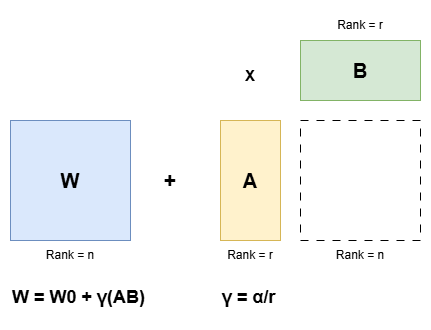

## QLoRA in one slide
- QLoRA means quantize the base model and train LoRA adapters.  
- Big cost reduction while still learning useful behavior changes.  
- Makes fine tuning possible on smaller GPUs.  
- Common for open source models when resources are limited.


## Prepare model for QLoRA training

In [14]:
model.config.use_cache = False
if hasattr(model.config, "pretraining_tp"):
    model.config.pretraining_tp = 1

model = prepare_model_for_kbit_training(model)
print("Model prepared for k-bit training.")


Model prepared for k-bit training.


## Format dataset text

In [16]:
eos = tokenizer.eos_token or ""
bos = tokenizer.bos_token or "<s>"

def clean_snippet(s: str) -> str:
    s = (s or "").strip()
    s = re.sub(r"\s+", " ", s)
    return s

def format_example(ex):
    q = (ex.get("question") or "").strip()
    a = clean_snippet(ex.get("text") or "")
    user = "Answer using company privacy policy text. Provide a short snippet.\n\nQuestion: " + q
    text = f"{bos}[INST] {user} [/INST] {a}"
    if eos and (not text.rstrip().endswith(eos)):
        text = text.rstrip() + eos
    return {"text": text}

train_dataset = train_raw.map(format_example, remove_columns=train_raw.column_names)

print("Train dataset columns:", train_dataset.column_names)
print("\nSample training text:\n", train_dataset[0]["text"][:500])


Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Train dataset columns: ['text']

Sample training text:
 <s>[INST] Answer using company privacy policy text. Provide a short snippet.

Question: if i delete the app how long is my data stored on their servers? [/INST] See our Third Law of Data Protection for more information.</s>


## Token length sanity check

In [17]:
sample_n = min(64, len(train_dataset))
lens = [len(tokenizer(train_dataset[i]["text"]).input_ids) for i in range(sample_n)]
print(f"Token lengths n={sample_n}: min={min(lens)}, p50={int(np.percentile(lens,50))}, p90={int(np.percentile(lens,90))}, max={max(lens)}")
print("max_seq_length:", max_seq_length, "packing:", packing)


Token lengths n=64: min=42, p50=62, p90=88, max=98
max_seq_length: 768 packing: False


## Build the trainer

In [18]:
peft_config = LoraConfig(
    r=lora_r,
    lora_alpha=lora_alpha,
    lora_dropout=lora_dropout,
    target_modules=lora_target_modules,
    bias="none",
    task_type="CAUSAL_LM",
)

sft_args = SFTConfig(
    output_dir=output_dir,
    num_train_epochs=num_train_epochs,
    per_device_train_batch_size=per_device_train_batch_size,
    gradient_accumulation_steps=gradient_accumulation_steps,
    learning_rate=learning_rate,
    weight_decay=weight_decay,
    max_grad_norm=max_grad_norm,
    warmup_ratio=warmup_ratio,
    lr_scheduler_type=lr_scheduler_type,
    logging_steps=logging_steps,
    save_strategy=save_strategy,
    report_to=["tensorboard"],
    seed=seed,

    fp16=(compute_dtype == torch.float16),
    bf16=(compute_dtype == torch.bfloat16),

    gradient_checkpointing=gradient_checkpointing,
    group_by_length=True,

    dataset_text_field="text",
    max_length=max_seq_length,
    packing=packing,

    optim="adamw_torch",
)

trainer = SFTTrainer(
    model=model,
    train_dataset=train_dataset,
    peft_config=peft_config,
    processing_class=tokenizer,
    args=sft_args,
)

print("Trainer ready.")
print_trainable_params(trainer.model)

trainable = sum(p.numel() for p in trainer.model.parameters() if p.requires_grad)
assert trainable > 0, "No trainable parameters found. LoRA adapters may not be attached."


Adding EOS to train dataset:   0%|          | 0/5000 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/5000 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/5000 [00:00<?, ? examples/s]

Trainer ready.
Trainable params: 39,976,960
Total params:     3,540,389,888
Trainable %:      1.1292%


## Start training

In [19]:
train_result = trainer.train()
print(train_result)

loss = getattr(train_result, "training_loss", None)
if loss is not None:
    print("Final training_loss:", loss)
    assert loss == loss, "training_loss is NaN."


{'loss': '4.138', 'grad_norm': '2.938', 'learning_rate': '2.368e-05', 'entropy': '1.639', 'num_tokens': '3916', 'mean_token_accuracy': '0.3961', 'epoch': '0.008'}
{'loss': '3.875', 'grad_norm': '2.328', 'learning_rate': '5e-05', 'entropy': '2.166', 'num_tokens': '6796', 'mean_token_accuracy': '0.4016', 'epoch': '0.016'}
{'loss': '2.692', 'grad_norm': '3.344', 'learning_rate': '7.632e-05', 'entropy': '2.895', 'num_tokens': '9280', 'mean_token_accuracy': '0.5352', 'epoch': '0.024'}
{'loss': '1.642', 'grad_norm': '3.734', 'learning_rate': '0.0001', 'entropy': '1.923', 'num_tokens': '1.152e+04', 'mean_token_accuracy': '0.6813', 'epoch': '0.032'}
{'loss': '1.08', 'grad_norm': '2.375', 'learning_rate': '9.998e-05', 'entropy': '1.144', 'num_tokens': '1.34e+04', 'mean_token_accuracy': '0.7496', 'epoch': '0.04'}
{'loss': '1.423', 'grad_norm': '1.016', 'learning_rate': '9.993e-05', 'entropy': '1.369', 'num_tokens': '1.753e+04', 'mean_token_accuracy': '0.6557', 'epoch': '0.048'}
{'loss': '1.326',

## Save LoRA adapters

In [20]:
trainer.model.save_pretrained(adapter_dir)
tokenizer.save_pretrained(adapter_dir)
print("Saved adapter to:", adapter_dir)


Saved adapter to: Spring26_privacy_qa_lora_adapter


## Inference after fine tuning

In [21]:
trainer.model.eval()
trainer.model.config.use_cache = True

q0 = make_policy_question(DEMO_QUESTION)
text_input = build_prompt(q0)
inputs = tokenizer(text_input, return_tensors="pt", add_special_tokens=False).to(trainer.model.device)

with torch.inference_mode():
    out_ids = trainer.model.generate(
        **inputs,
        max_new_tokens=120,
        do_sample=False,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.pad_token_id,
        repetition_penalty=1.1,
        no_repeat_ngram_size=4,
    )

decoded = tokenizer.decode(out_ids[0], skip_special_tokens=False)
print("Question:\n", DEMO_QUESTION)
print("\nFine tuned answer:\n", extract_answer(decoded))


Question:
 if i delete the app how long is my data stored on their servers?

Fine tuned answer:
 We will retain your personal information for as long as you have an open account with us.</s> In addition, we may retain your personal data for legitimate business purposes or as required by law.</s> For example, we may keep your personal data to:</s> resolve any outstanding issues related to your account; and</s> prevent fraud and protect our business and customers.</s> When we no longer need your personal data, we will dispose of it in a secure manner.</s> Please note that we will not retain your Content for as long.</s> Once you


## Method 1 load adapter and infer

In [22]:
# Free trainer model memory, then reload from disk
for _name in ["trainer", "model"]:
    if _name in globals():
        try:
            del globals()[_name]
        except Exception:
            pass
cuda_cleanup()

tokenizer = AutoTokenizer.from_pretrained(adapter_dir, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map=device_map,
)
ft_model = PeftModel.from_pretrained(base_model, adapter_dir)
ft_model.eval()
ft_model.config.use_cache = True

q0 = make_policy_question(DEMO_QUESTION)
text_input = build_prompt(q0)
inputs = tokenizer(text_input, return_tensors="pt", add_special_tokens=False).to(ft_model.device)

with torch.inference_mode():
    out_ids = ft_model.generate(
        **inputs,
        max_new_tokens=120,
        do_sample=False,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.pad_token_id,
        repetition_penalty=1.1,
        no_repeat_ngram_size=4,
    )

decoded = tokenizer.decode(out_ids[0], skip_special_tokens=False)
print("Question:\n", DEMO_QUESTION)
print("\nReloaded adapter answer:\n", extract_answer(decoded))


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Question:
 if i delete the app how long is my data stored on their servers?

Reloaded adapter answer:
 We will retain your personal information for as long as you have an open account with us.</s> In addition, we may retain your personal data for legitimate business purposes or as required by law.</s> For example, we may keep your personal data to:</s> resolve any outstanding issues related to your account; and</s> prevent fraud and protect our business and customers.</s> When we no longer need your personal data, we will dispose of it in a secure manner.</s> Please note that we will not retain your Content for as long.</s> Once you


## Method 2 merge and save

In [23]:
# from peft import PeftModel
# import torch
#
# merged_dir = "Spring26_privacy_qa_merged_fp16"
#
# for _name in ["ft_model", "base_model"]:
#     if _name in globals():
#         try:
#             del globals()[_name]
#         except Exception:
#             pass
# cuda_cleanup()
#
# base_fp16 = AutoModelForCausalLM.from_pretrained(
#     model_name,
#     torch_dtype=torch.float16,
#     device_map="auto",
# )
#
# tok = AutoTokenizer.from_pretrained(adapter_dir, use_fast=True)
# if tok.pad_token is None:
#     tok.pad_token = tok.eos_token
#
# peft_fp16 = PeftModel.from_pretrained(base_fp16, adapter_dir)
# merged = peft_fp16.merge_and_unload()
#
# merged.save_pretrained(merged_dir, safe_serialization=True)
# tok.save_pretrained(merged_dir)
#
# print("Saved merged model to:", merged_dir)


## Method 2 infer merged model

In [24]:
# import torch
#
# merged_dir = "Spring26_privacy_qa_merged_fp16"
# tok = AutoTokenizer.from_pretrained(merged_dir, use_fast=True)
# if tok.pad_token is None:
#     tok.pad_token = tok.eos_token
#
# merged_model = AutoModelForCausalLM.from_pretrained(
#     merged_dir,
#     torch_dtype=torch.float16,
#     device_map="auto",
# )
# merged_model.eval()
#
# def build_prompt_local(user_message: str) -> str:
#     user_message = user_message.strip()
#     if hasattr(tok, "apply_chat_template") and getattr(tok, "chat_template", None):
#         messages = [{"role": "user", "content": user_message}]
#         return tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
#     bos = tok.bos_token or "<s>"
#     return f"{bos}[INST] {user_message} [/INST]"
#
# q0 = (
#     "You are a helpful assistant that answers using company privacy policy text. "
#     "Answer with a short policy snippet.\n\n"
#     f"Question: {DEMO_QUESTION}"
# )
# text_input = build_prompt_local(q0)
# inputs = tok(text_input, return_tensors="pt", add_special_tokens=False).to(merged_model.device)
#
# with torch.inference_mode():
#     out_ids = merged_model.generate(
#         **inputs,
#         max_new_tokens=120,
#         do_sample=False,
#         eos_token_id=tok.eos_token_id,
#         pad_token_id=tok.pad_token_id,
#         repetition_penalty=1.1,
#         no_repeat_ngram_size=4,
#     )
#
# decoded = tok.decode(out_ids[0], skip_special_tokens=False)
# ans = decoded.split("[/INST]", 1)[-1].strip() if "[/INST]" in decoded else decoded.strip()
# print("Merged model answer:\n", ans)
